# 01 探索性数据分析 (EDA)

参考项目：`/home/ye/data-science/Kaggle-Home-Credit-Default-Risk-Solution/EDA.ipynb`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '/home/ye/data-science/home-credit-default-risk/data/'
application_train = DATA_DIR + "application_train.csv"
df = pd.read_csv(application_train)
shape = df.shape
head = df.head()
info = df.info()
des = df.describe()
print(shape)
print("="*60)
print(head)
print("="*60)
print(info)
print("="*60)
print(des)
print(df.select_dtypes(include='object'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
(307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0  

In [3]:
object_columns = df.select_dtypes(include='object')
object_columns_name = object_columns.columns
print(object_columns_name)

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [4]:
object_columns_nunique = []
for i in object_columns_name:
    object_columns_nunique.append(df[i].nunique())
print(object_columns_nunique)

[2, 3, 2, 2, 7, 8, 5, 6, 6, 18, 7, 58, 4, 3, 7, 2]


In [6]:
df.value_counts()

SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  NAME_TYPE_SUITE  NAME_INCOME_TYPE      NAME_EDUCATION_TYPE            NAME_FAMILY_STATUS    NAME_HOUSING_TYPE    REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL  OCCUPATION_TYPE  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY  WEEKDAY_APPR_PROCESS_START  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY  ORGANIZATION_TYPE       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  FLOORSMAX_AVG  FLOORSMIN_AVG  LANDAREA_AVG  LIVING

In [7]:
missing_count = df.isnull().sum()
missing_gt0 = missing_count[missing_count>0]

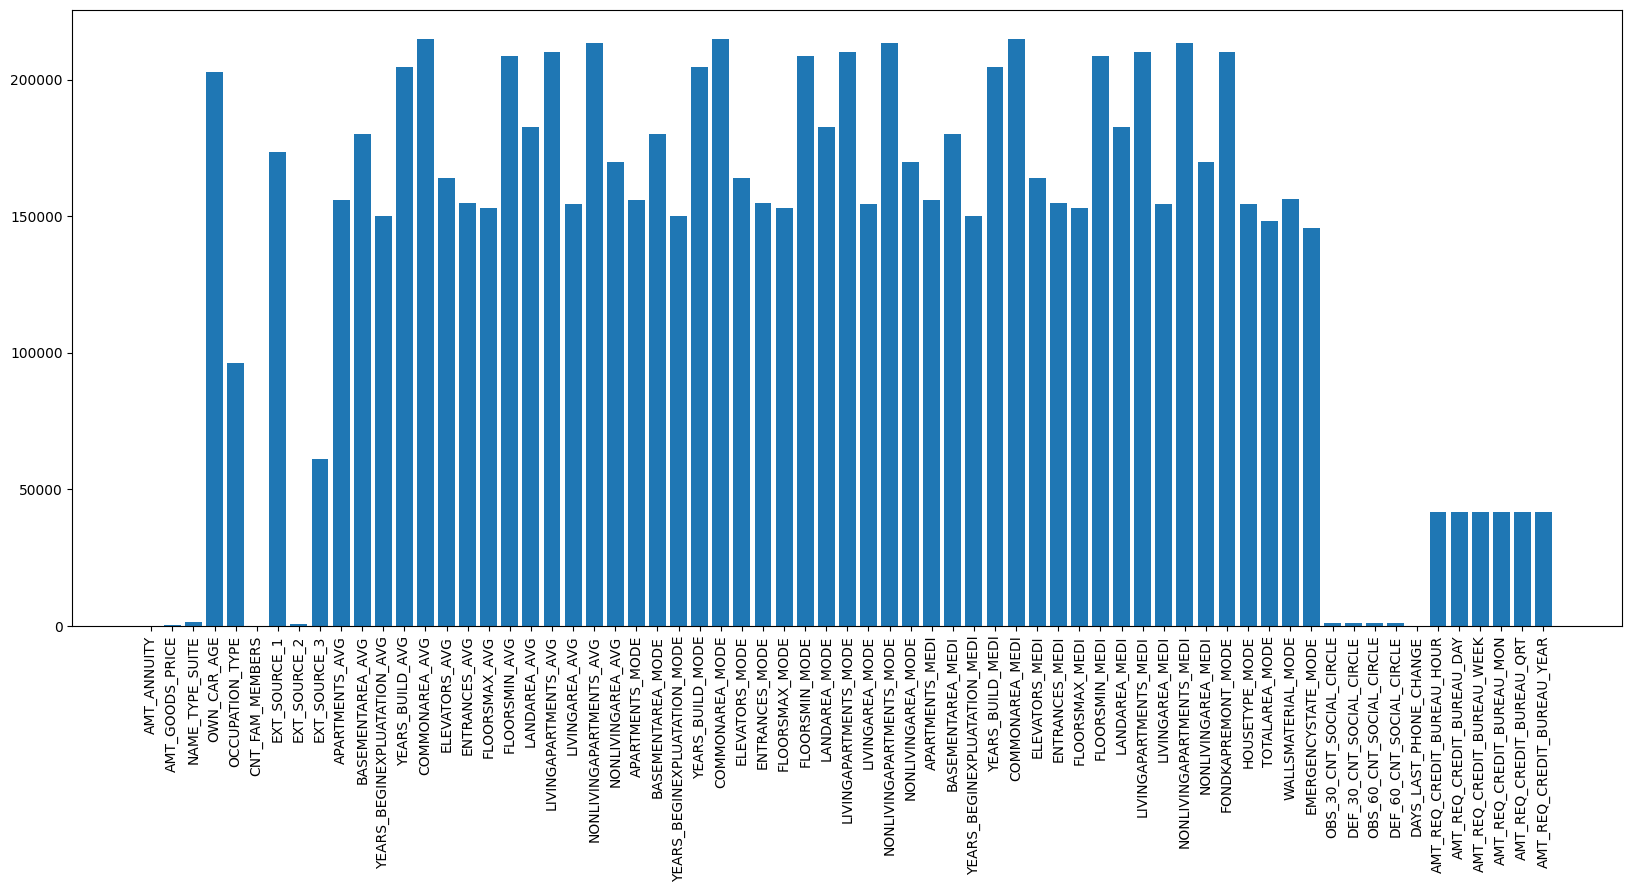

In [8]:

plt.figure(figsize=(20,8))
plt.bar(missing_gt0.index,missing_gt0.values)
plt.xticks(rotation=90)
plt.show()



In [10]:
(missing_gt0 / len(df) * 100 ).sort_values(ascending=False).to_string()

'COMMONAREA_MEDI                 69.872297\nCOMMONAREA_MODE                 69.872297\nCOMMONAREA_AVG                  69.872297\nNONLIVINGAPARTMENTS_MODE        69.432963\nNONLIVINGAPARTMENTS_MEDI        69.432963\nNONLIVINGAPARTMENTS_AVG         69.432963\nFONDKAPREMONT_MODE              68.386172\nLIVINGAPARTMENTS_AVG            68.354953\nLIVINGAPARTMENTS_MEDI           68.354953\nLIVINGAPARTMENTS_MODE           68.354953\nFLOORSMIN_MEDI                  67.848630\nFLOORSMIN_MODE                  67.848630\nFLOORSMIN_AVG                   67.848630\nYEARS_BUILD_MODE                66.497784\nYEARS_BUILD_MEDI                66.497784\nYEARS_BUILD_AVG                 66.497784\nOWN_CAR_AGE                     65.990810\nLANDAREA_AVG                    59.376738\nLANDAREA_MEDI                   59.376738\nLANDAREA_MODE                   59.376738\nBASEMENTAREA_MODE               58.515956\nBASEMENTAREA_MEDI               58.515956\nBASEMENTAREA_AVG                58.515956\nEXT_SOURCE